# 1. Import and Install Dependencies

## 1.2 Load Dependencies

In [1]:
import os
from matplotlib import pyplot as plt
import tensorflow as tf 
import tensorflow_io as tfio
from split_audio_by_duration import split_audio_by_duration 

ModuleNotFoundError: No module named 'tensorflow'

# 2. Build Data Loading Function

## 2.1 Define Paths to Files

In [2]:
POSITIVE_FILE = os.path.join('audios', 'positive', '0.wav')
NEGATIVE_FILE = os.path.join('audios', 'negative', '0.wav')


In [3]:
file_contents = tf.io.read_file(POSITIVE_FILE)
file_contents

<tf.Tensor: shape=(), dtype=string, numpy=b'RIFF$\xfa\x00\x00WAVEfmt \x10\x00\x00\x00\x01\x00\x02\x00\x80>\x00\x00\x00\xfa\x00\x00\x04\x00\x10\x00data\x00\xfa\x00\x00\x1c\x1b\x1c\x1b\x1c\x1b\x1c\x1b(\x08(\x08h\x06h\x06\x19\xd6\x19\xd6\xfd\xd7\xfd\xd7z\x18z\x18z\x18z\x18\x8e\x1c\x8e\x1c\\\x1a\\\x1aN0N0N0N0Y-Y-Y-Y-*:*:*:*:5Z5Z5Z5Zt\xbdt\xbdt\xbdt\xbd\x03\xe7\x03\xe7\xf9\xe7\xf9\xe7\x16\xf2\x16\xf2E\xf2E\xf2\x1a\xa1\x1a\xa1\xdb\xa1\xdb\xa1[\xc2[\xc2\x18\xc2\x18\xc2\x0b\xdc\x0b\xdc\xeb\xdb\xeb\xdbN+N+o+o+q\x03q\x03t\x03t\x03\xb0\x1a\xb0\x1a\xbe\x1a\xbe\x1a{\xe7{\xe7{\xe7{\xe7\xe3\xd2\xe3\xd2\xa6\xd2\xa6\xd2\xdf\xe5\xdf\xe5\xdf\xe5\xdf\xe5S\xc6S\xc6S\xc6S\xc6\xb8\xcd\xb8\xcd\xb8\xcd\xb8\xcd\xce\xc7\xce\xc7\xce\xc7\xce\xc7\xcc0\xcc0\xcc0\xcc0\xb0\xf2\xb0\xf2\xb0\xf2\xb0\xf2\x85\xdb\x85\xdb\x85\xdb\x85\xdb\xca\xeb\xca\xeb\xca\xeb\xca\xeb\x94\xd7\x94\xd7\x94\xd7\x94\xd72\x152\x152\x152\x15l\xbfl\xbfl\xbfl\xbf\x94\xb4\x94\xb4\x94\xb4\x94\xb4\x93\x1d\x93\x1d\x93\x1d\x93\x1d]\t]\t]\t]\th\xe3h\xe3

In [4]:
wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
sample_rate

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

## 2.2 Build Dataloading Function

In [5]:
def load_wav_16k_mono(filename):
    # Load encoded wav file
    file_contents = tf.io.read_file(filename)
    # Decode wav (tensors by channels) 
    wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
    # Removes trailing axis
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # Goes from 44100Hz to 16000hz - amplitude of the audio signal
    wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

## 2.3 Plot Wave

In [6]:
wave = load_wav_16k_mono(POSITIVE_FILE)
nwave = load_wav_16k_mono(NEGATIVE_FILE)

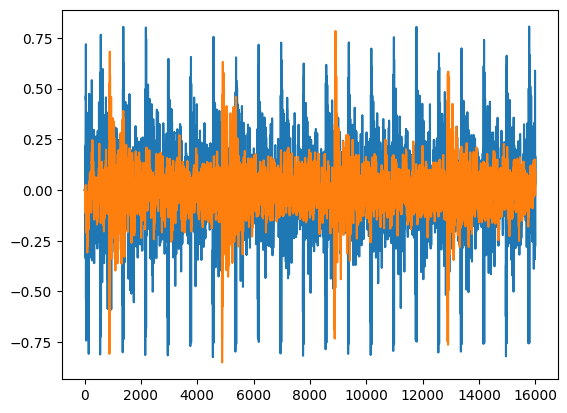

In [7]:
plt.plot(wave)
plt.plot(nwave)
plt.show()

# 3. Create Tensorflow Dataset

## 3.1 Define Paths to Positive and Negative Data

In [8]:
POS = os.path.join('./', 'audios', 'positive')
NEG = os.path.join('./', 'audios', 'negative')

## 3.2 Create Tensorflow Datasets

In [9]:
pos = tf.data.Dataset.list_files(POS+'\*.wav')
neg = tf.data.Dataset.list_files(NEG+'\*.wav')

## 3.3 Add labels and Combine Positive and Negative Samples

In [10]:
positives = tf.data.Dataset.zip((pos, tf.data.Dataset.from_tensor_slices(tf.ones(len(pos)))))
negatives = tf.data.Dataset.zip((neg, tf.data.Dataset.from_tensor_slices(tf.zeros(len(neg)))))
data = positives.concatenate(negatives)

# 4. Determine Average Length of a file

## 4.1 Calculate Wave Cycle Length

In [11]:
lengths = []
for file in os.listdir(os.path.join('./', 'audios', 'positive')):
    tensor_wave = load_wav_16k_mono(os.path.join('./', 'audios', 'positive', file))
    lengths.append(len(tensor_wave))

## 4.2 Calculate Mean, Min and Max

In [12]:
tf.math.reduce_mean(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

In [13]:
tf.math.reduce_min(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

In [14]:
tf.math.reduce_max(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

# 5. Build Preprocessing Function to Convert to Spectrogram

## 5.1 Build Preprocessing Function

In [15]:
def preprocess(file_path, label):
    wav = load_wav_16k_mono(file_path)
    wav = wav[:16000]
    zero_padding = tf.zeros([16000] - tf.shape(wav), dtype=tf.float32)
    wav = tf.concat([zero_padding, wav],0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram, label

## 5.2 Test Out the Function and Viz the Spectrogram

In [16]:
filepath, label = positives.shuffle(buffer_size=10000).as_numpy_iterator().next()

In [17]:
spectrogram, label = preprocess(filepath, label)

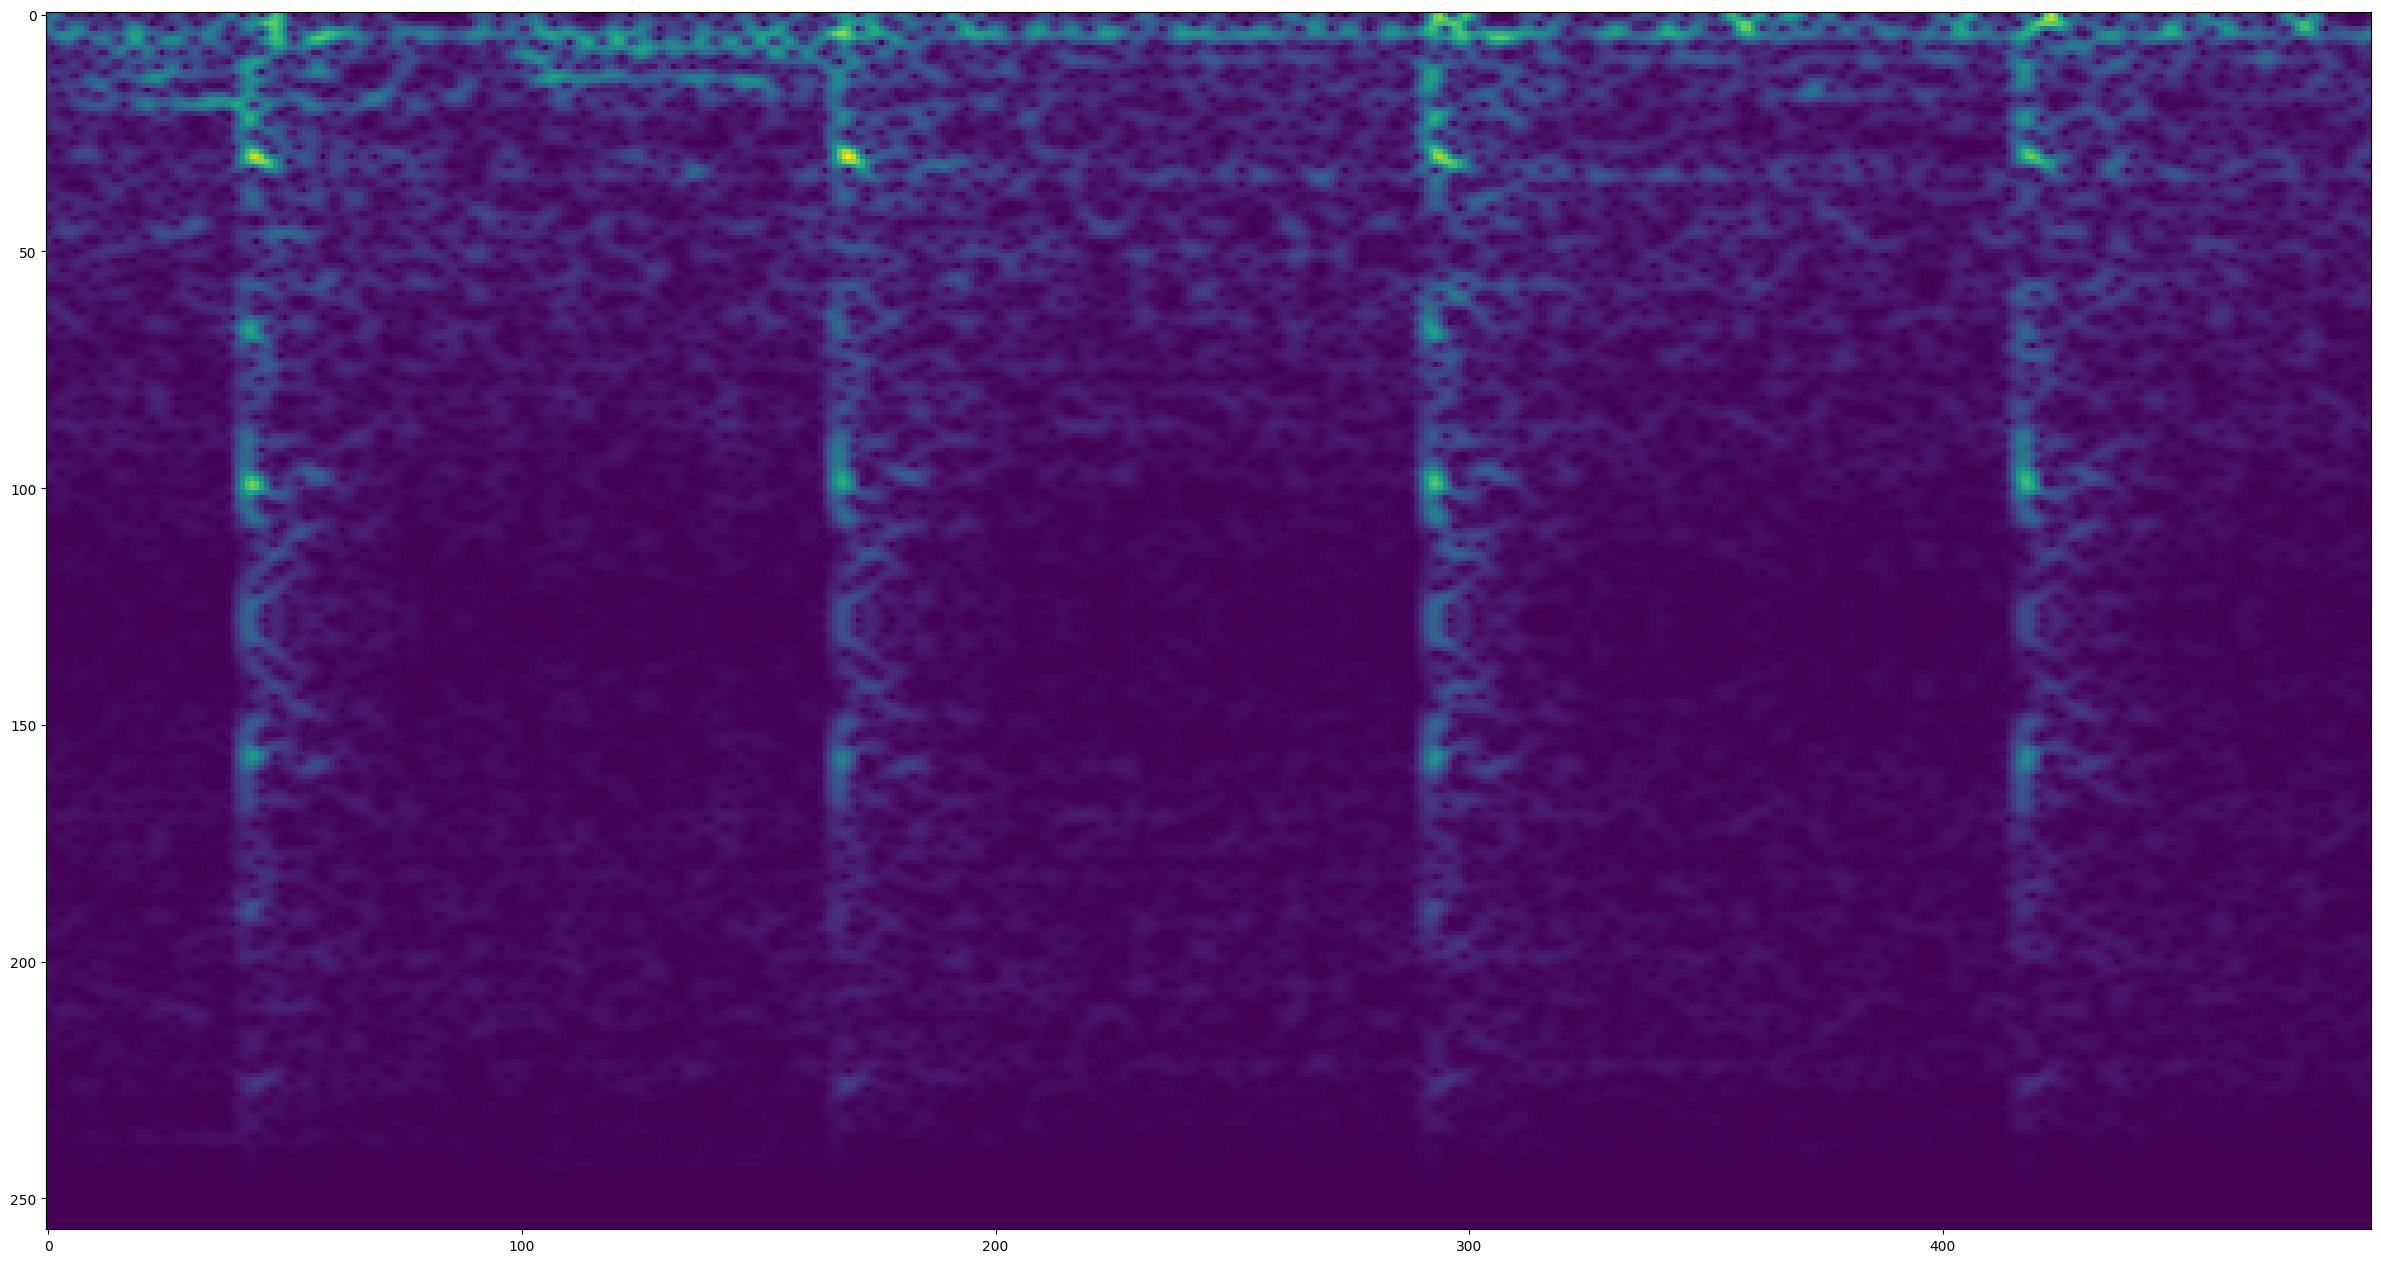

In [18]:
plt.figure(figsize=(30,20))
plt.imshow(tf.transpose(spectrogram)[0])
plt.show()

# 6. Create Training and Testing Partitions

## 6.1 Create a Tensorflow Data Pipeline

In [19]:
print(len(data))
data = data.map(preprocess)
data = data.cache()
data = data.shuffle(buffer_size=1000)
data = data.batch(16)
data = data.prefetch(8)

236
<ConcatenateDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))>
Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089
<MapDataset element_spec=(TensorSpec(shape=<unknown>, dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))>
<CacheDataset element_spec=(TensorSpec(shape=<unknown>, dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))>
<ShuffleDataset element_spec=(TensorSpec(shape=<unknown>, dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))>
<BatchDataset element_spec=(TensorSpec(shape=<unknown>, dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>
<PrefetchDataset element_spec=(TensorSpec(shape=<unknown>, dtype=tf.float32, name=None), TensorSpec(sh

## 6.2 Split into Training and Testing Partitions

In [20]:
len(data)*.8

12.0

In [21]:
train = data.take(int(len(data)*.8))
test = data.skip(int(len(data)*.8)).take(int(len(data)-len(data)*.8))

## 6.3 Test One Batch

In [22]:
samples, labels = train.as_numpy_iterator().next()

In [23]:
labels

array([1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1.],
      dtype=float32)

In [24]:
samples.shape

(16, 491, 257, 1)

# 7. Build Deep Learning Model

## 7.1 Load Tensorflow Dependencies

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten

## 7.2 Build Sequential Model, Compile and View Summary

In [26]:
model = Sequential()
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(491, 257,1)))
model.add(Conv2D(16, (3,3), activation='relu'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [27]:
model.compile('Adam', loss='BinaryCrossentropy', metrics=[tf.keras.metrics.Recall(),tf.keras.metrics.Precision()])

In [28]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 489, 255, 16)      160       
                                                                 
 conv2d_1 (Conv2D)           (None, 487, 253, 16)      2320      
                                                                 
 flatten (Flatten)           (None, 1971376)           0         
                                                                 
 dense (Dense)               (None, 128)               252336256 
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 252,338,865
Trainable params: 252,338,865
Non-trainable params: 0
_________________________________________________________________


## 7.3 Fit Model, View Loss and KPI Plots

In [29]:
hist = model.fit(train, epochs=4, validation_data=test)

Epoch 1/4


 5/12 [===========>..................] - ETA: 16s - loss: 76.4517 - recall: 0.6364 - precision: 0.8077

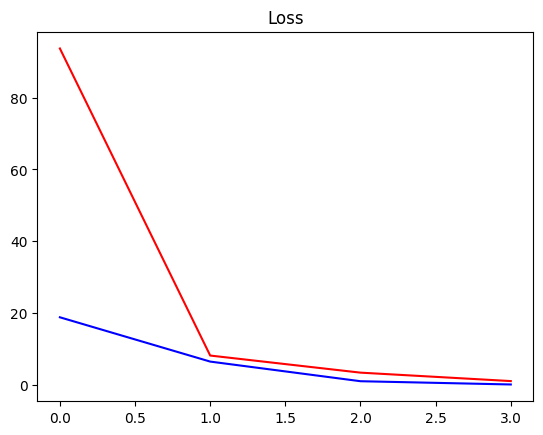

In [ ]:
plt.title('Loss')
plt.plot(hist.history['loss'], 'r')
plt.plot(hist.history['val_loss'], 'b')
plt.show()

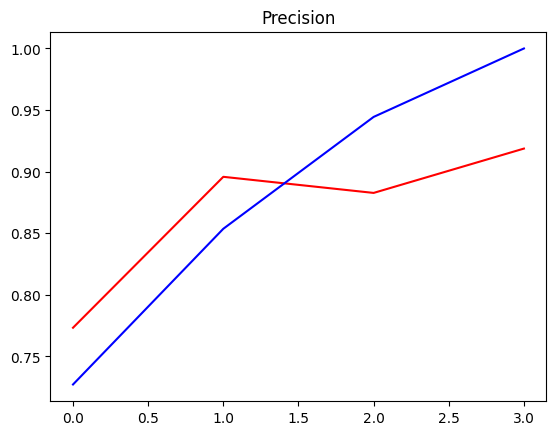

In [ ]:
plt.title('Precision')
plt.plot(hist.history['precision'], 'r')
plt.plot(hist.history['val_precision'], 'b')
plt.show()

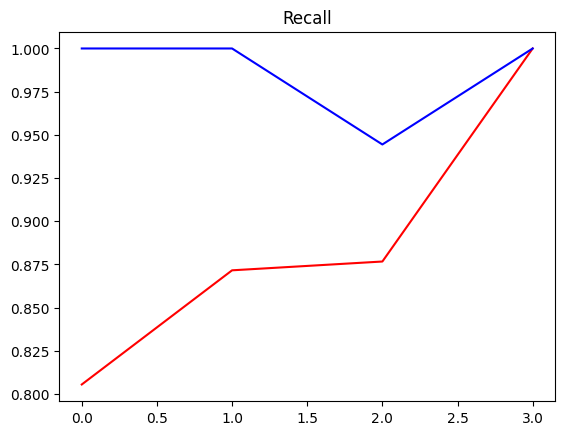

In [ ]:
plt.title('Recall')
plt.plot(hist.history['recall'], 'r')
plt.plot(hist.history['val_recall'], 'b')
plt.show()

# 8. Make a Prediction on a Single Clip

## 8.1 Get One Batch and Make a Prediction

In [ ]:
X_test, y_test = test.as_numpy_iterator().next()
print(X_test.shape)
print(y_test.shape)
print(X_test)
print(y_test)

(16, 491, 257, 1)
(16,)
[[[[1.24842715e+00]
   [1.27156949e+00]
   [1.87765718e+00]
   ...
   [1.44454115e-03]
   [2.85143644e-04]
   [5.13195992e-05]]

  [[1.20780826e+00]
   [1.57738650e+00]
   [2.05593348e+00]
   ...
   [1.36030943e-03]
   [6.07547467e-04]
   [2.67267227e-04]]

  [[6.05811596e-01]
   [1.75543988e+00]
   [2.12512016e+00]
   ...
   [7.73318287e-04]
   [9.41976905e-04]
   [6.64353371e-04]]

  ...

  [[1.09738960e+01]
   [9.68147182e+00]
   [6.11657238e+00]
   ...
   [1.98694295e-03]
   [1.21075893e-03]
   [6.06060028e-04]]

  [[8.87351513e+00]
   [8.10275841e+00]
   [4.50589037e+00]
   ...
   [9.30003007e-04]
   [1.34129717e-03]
   [1.25789642e-03]]

  [[5.51203442e+00]
   [5.71786737e+00]
   [4.71637678e+00]
   ...
   [2.18474865e-03]
   [1.30370294e-03]
   [2.21729279e-03]]]


 [[[1.37216473e+01]
   [1.27223434e+01]
   [9.19442368e+00]
   ...
   [1.80450524e-03]
   [1.60428684e-03]
   [5.71727753e-04]]

  [[1.24114475e+01]
   [1.22176533e+01]
   [9.29127121e+00]
   .

In [ ]:
yhat = model.predict(X_test)
yhat[:3]

1/1 [==============================] - 0s 138ms/step


array([[1.0000000e+00],
       [2.4750571e-11],
       [9.9999923e-01]], dtype=float32)

## 8.2 Convert Logits to Classes 

In [ ]:
SCHWELLENWERT = 0.5
yhat = [1 if prediction > SCHWELLENWERT else 0 for prediction in yhat]
yhat

[1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1]

In [ ]:
print(tf.math.reduce_sum(yhat))
print(tf.math.reduce_sum(y_test))

tf.Tensor(10, shape=(), dtype=int32)
tf.Tensor(9.0, shape=(), dtype=float32)


In [ ]:
print(yhat)
print(y_test.astype(int))

[1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1]
[1 1 1 0 0 1 0 0 1 1 1 1 1 1 1 1]


# 9. Build Forest Parsing Functions

## 9.1 Load up WAVs

In [ ]:
wav_path = os.path.join('./', 'audios', 'test', 'rec2.wav')
#wav_path = os.path.join('./', 'audios', 'test', 'rec2.wav')
#wav_path = os.path.join('./', 'audios', 'test', 'rec8.wav')

In [ ]:
wav = load_wav_16k_mono(wav_path)
wav.shape

TensorShape([479232])

In [ ]:
audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=16000, sequence_stride=16000, batch_size=1)

In [ ]:
samples, index = audio_slices.as_numpy_iterator().next()

In [ ]:
len(audio_slices)

29

In [ ]:
samples.shape

(1, 16000)

## 9.2 Build Function to Convert Clips into Windowed Spectrograms

In [ ]:
def preprocess_2(sample, index):
    sample = sample[0]
    zero_padding = tf.zeros([16000] - tf.shape(sample), dtype=tf.float32)
    wav = tf.concat([zero_padding, sample],0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram

## 9.3 Convert Longer Clips into Windows and Make Predictions

In [ ]:
audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=16000, sequence_stride=16000, batch_size=1)
audio_slices = audio_slices.map(preprocess_2)
audio_slices = audio_slices.batch(64)

In [ ]:
yhat = model.predict(audio_slices)
yhat = [1 if prediction > 0.52 else 0 for prediction in yhat]
yhat

1/1 [==============================] - 0s 359ms/step


[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

## 9.4 Group Consecutive Detections

In [ ]:
from itertools import groupby

In [ ]:
yhat = [key for key, group in groupby(yhat)]
calls = tf.math.reduce_sum(yhat).numpy()

In [ ]:
calls

0

# 10. Make Predictions

## 10.1 Loop over all recordings and make predictions

In [ ]:
results = {}
for file in os.listdir(os.path.join('data', 'Forest Recordings')):
    FILEPATH = os.path.join('data','Forest Recordings', file)
    
    wav = load_mp3_16k_mono(FILEPATH)
    audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=48000, sequence_stride=48000, batch_size=1)
    audio_slices = audio_slices.map(preprocess_mp3)
    audio_slices = audio_slices.batch(64)
    
    yhat = model.predict(audio_slices)
    
    results[file] = yhat

FileNotFoundError: [WinError 3] Das System kann den angegebenen Pfad nicht finden: 'data\\Forest Recordings'

In [ ]:
results

## 10.2 Convert Predictions into Classes

In [ ]:
class_preds = {}
for file, logits in results.items():
    class_preds[file] = [1 if prediction > 0.99 else 0 for prediction in logits]
class_preds

## 10.3 Group Consecutive Detections

In [ ]:
postprocessed = {}
for file, scores in class_preds.items():
    postprocessed[file] = tf.math.reduce_sum([key for key, group in groupby(scores)]).numpy()
postprocessed

# 11. Export Results

In [ ]:
import csv

In [ ]:
with open('results.csv', 'w', newline='') as f:
    writer = csv.writer(f, delimiter=',')
    writer.writerow(['recording', 'capuchin_calls'])
    for key, value in postprocessed.items():
        writer.writerow([key, value])